# Analysis of the profitability of the discounts — Superstore

**Objective :** Build a Random Forest model to predict if a discount is **profitable** or not and identify parameters in which discounts have the better impact (customers, region, category)

**Analysis logic :** A discount is profitable is the revenue generated with the discount is **superior to the mean revenue without discount** for the same sub category.


## 1. Imports & Configuration

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

# Global plots style         
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['axes.titlesize'] = 13

print('✅ Imports OK')

✅ Imports OK


## 2. Loading and first data cleaning

The CSV given has many specificities to handle :
- Séparateur `,`
- Revenues with `$` and spaces                                
- Discounts in `%`
- Dates in `MM/DD/YYYY`

In [15]:
# --- Loading ---
df = pd.read_csv('excel_project_s2.csv', sep=',', encoding='utf-8-sig')

# Cleaning names of the columns
df.columns = df.columns.str.strip()

# --- Cleaning monetary columns ---
def clean_money(col):
    """Removes $,spacesx, replaces , par . and converts to float."""
    return (
        col.astype(str)
           .str.replace('$', '', regex=False)
           .str.replace('\xa0', '', regex=False)
           .str.replace(' ', '', regex=False)
           .str.replace(',', '', regex=False)
           .astype(float)
    )

df['Total Amount'] = clean_money(df['Total Amount'])
df['Total Amount After the Discount'] = clean_money(df['Total Amount After the Discount'])

# --- Cleaning discounts ---
df['Discount'] = (
    df['Discount'].astype(str)
                  .str.replace('%', '', regex=False)
                  .str.replace(',', '.', regex=False)
                  .astype(float) / 100
)

# --- Parsing of dates ---
df['Order Date'] = pd.to_datetime(df['Order Date'], format='%m/%d/%Y')
df['Ship Date']  = pd.to_datetime(df['Ship Date'],  format='%m/%d/%Y')

# --- Cleaning strings ---
df['City']  = df['City'].str.strip()
df['State'] = df['State'].str.strip()

print(f'✅ Dataset loaded : {df.shape[0]} rows, {df.shape[1]} columns')
df.head(3)

✅ Dataset loaded : 150 rows, 21 columns


,Order ID,Customer ID,Customer Name,Product ID,Product Name,Postal Code,City,State,Order Date,Total Amount,...,Discount,Ship Date,Category,Sub-Category,Ship Mode,Segment,Region,Regional Manager,Regional Manager Email,Total Amount After the Discount
0,CA-2016-152156,CG-12520,Claire Gute,FUR-BO-10001798,Bush Somerset Collection Bookcase,42420,Henderson,Kentucky,2016-11-08,261.96,...,0.00,2016-11-11,Furniture,Bookcases,Second Class,CONSUMER,South,Charlie Brown,cbrown@superstore.com,261.96
1,CA-2016-152156,CG-12520,Claire Gute,FUR-CH-10000454,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",42420,Henderson,Kentucky,2016-11-08,731.94,...,0.00,2016-11-11,Furniture,Chairs,Second Class,CONSUMER,South,Charlie Brown,cbrown@superstore.com,731.94
2,US-2015-108966,SO-20335,Sean O'Donnell,FUR-TA-10000577,Bretford CR4500 Series Slim Rectangular Table,33311,Fort Lauderdale,Florida,2015-10-11,957.58,...,0.45,2015-10-18,Furniture,Tables,Standard Class,CONSUMER,South,Charlie Brown,cbrown@superstore.com,526.67


In [16]:
# Verification of missing values  
missing = df.isnull().sum()
print('Missing values by column :')
print(missing[missing > 0] if missing.any() else '  Aucune ✅')

print('\nType of numeric columns :')
print(df[['Total Amount', 'Total Amount After the Discount', 'Discount', 'Quantity']].dtypes)

Missing values by column :
  Aucune ✅

Type of numeric columns :
Total Amount                       float64
Total Amount After the Discount    float64
Discount                           float64
Quantity                             int64
dtype: object


## 3. Feature Engineering

### 3.1 Target variable : `remise_rentable`

We compute the **mean revenue per unit with no discount** for each sub-category then check if the real revenue registered of the order is higher.

In [17]:
# Unary real price
df['prix_unitaire_paye'] = df['Total Amount After the Discount'] / df['Quantity']

# Mean price withouut discount per sub-category ( only for orders without discount)
prix_ref = (
    df[df['Discount'] == 0]
    .groupby('Sub-Category')['prix_unitaire_paye']
    .mean()
    .rename('prix_ref_unitaire')
)

df = df.merge(prix_ref, on='Sub-Category', how='left')

# For categories missing data -> We take the global median
fallback = df[df['Discount'] == 0]['prix_unitaire_paye'].median()
df['prix_ref_unitaire'] = df['prix_ref_unitaire'].fillna(fallback)

# Reference revenue if we didn't apply the discount in the same quantity 
df['revenu_reference'] = df['prix_ref_unitaire'] * df['Quantity']

# Discount is worth if real revenur >= reference revenue (mean of prices of orders without one)
df['remise_rentable'] = (df['Total Amount After the Discount'] >= df['revenu_reference']).astype(int)

# We apply this only to commands with a discount
df_remise = df[df['Discount'] > 0].copy()

print(f'Orders with discount : {len(df_remise)}')
print(f"\nDistribution of the target value: ")
print(df_remise['remise_rentable'].value_counts().rename({0: 'Non rentable', 1: 'Rentable'}))

Orders with discount : 73

Distribution of the target value: 
remise_rentable
Non rentable    52
Rentable        21
Name: count, dtype: int64


### 3.2 New features

In [18]:
# Delivery time in days
df_remise['delai_livraison'] = (df_remise['Ship Date'] - df_remise['Order Date']).dt.days

# Month and year of the order
df_remise['mois_commande'] = df_remise['Order Date'].dt.month
df_remise['annee_commande'] = df_remise['Order Date'].dt.year

# Loss due to the discount
df_remise['perte_remise'] = df_remise['Total Amount'] - df_remise['Total Amount After the Discount']

print('✅ Features créées')
df_remise[['Discount', 'Quantity', 'delai_livraison', 'perte_remise', 'remise_rentable']].describe()

✅ Features créées


,Discount,Quantity,delai_livraison,perte_remise,remise_rentable
count,73.000000,73.000000,73.000000,73.000000,73.000000
mean,0.310548,4.178082,4.164384,72.905068,0.287671
std,0.199819,2.468369,1.462624,193.934304,0.455810
min,0.100000,1.000000,1.000000,0.650000,0.000000
25%,0.200000,2.000000,3.000000,5.450000,0.000000
50%,0.200000,3.000000,4.000000,18.780000,0.000000
75%,0.300000,6.000000,5.000000,48.800000,1.000000
max,0.800000,14.000000,7.000000,1541.710000,1.000000


## 4. Exploratory analysis

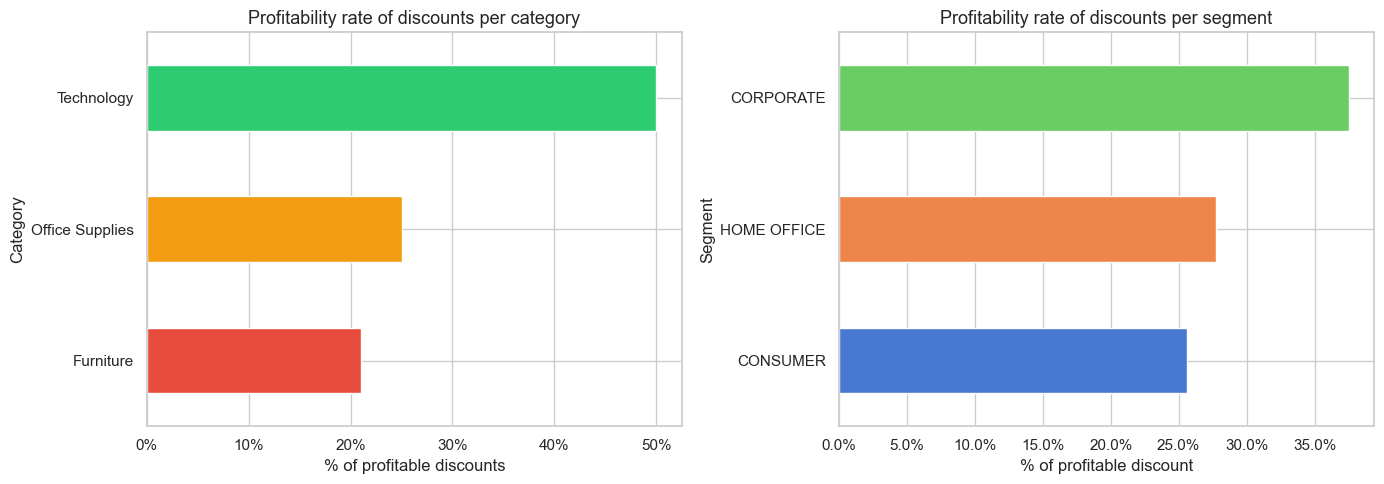

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Profitability rate per category
cat_rentab = df_remise.groupby('Category')['remise_rentable'].mean().sort_values()
cat_rentab.plot(kind='barh', ax=axes[0], color=['#e74c3c','#f39c12','#2ecc71'])
axes[0].set_title('Profitability rate of discounts per category')
axes[0].xaxis.set_major_formatter(mticker.PercentFormatter(1.0))
axes[0].set_xlabel('% of profitable discounts')

# Profitabilty rate per segment
seg_rentab = df_remise.groupby('Segment')['remise_rentable'].mean().sort_values()
seg_rentab.plot(kind='barh', ax=axes[1], color=sns.color_palette('muted', 3))
axes[1].set_title('Profitability rate of discounts per segment')
axes[1].xaxis.set_major_formatter(mticker.PercentFormatter(1.0))
axes[1].set_xlabel('% of profitable discount')

plt.tight_layout()
plt.savefig('plots/rentabilite_categorie_segment.png', dpi=150, bbox_inches='tight')
plt.show()

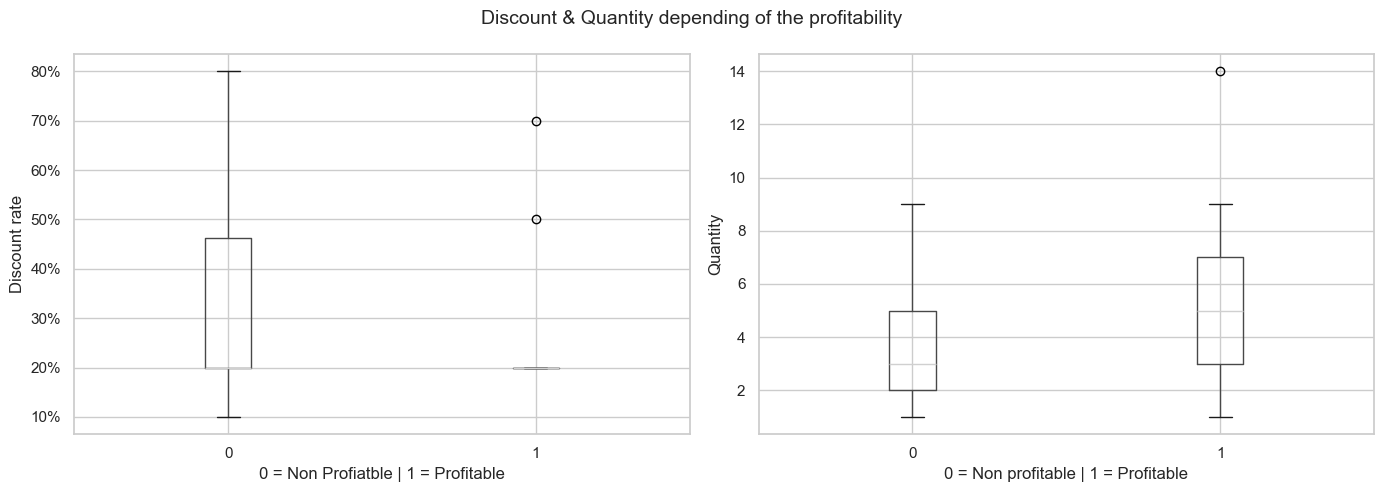

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribution du taux de remise selon la rentabilité
df_remise.boxplot(column='Discount', by='remise_rentable', ax=axes[0])
axes[0].set_title('Discount rate: Profitable vs non profitable')
axes[0].set_xlabel('0 = Non Profiatble | 1 = Profitable')
axes[0].set_ylabel('Discount rate')
axes[0].yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
plt.sca(axes[0])
plt.title('')

# Quantité commandée selon la rentabilité
df_remise.boxplot(column='Quantity', by='remise_rentable', ax=axes[1])
axes[1].set_title('Quantité commandée : Rentable vs Non rentable')
axes[1].set_xlabel('0 = Non profitable | 1 = Profitable')
axes[1].set_ylabel('Quantity')
plt.sca(axes[1])
plt.title('')

fig.suptitle('Discount & Quantity depending of the profitability', fontsize=14)
plt.tight_layout()
plt.savefig('plots/distribution_remise_quantite.png', dpi=150, bbox_inches='tight')
plt.show()

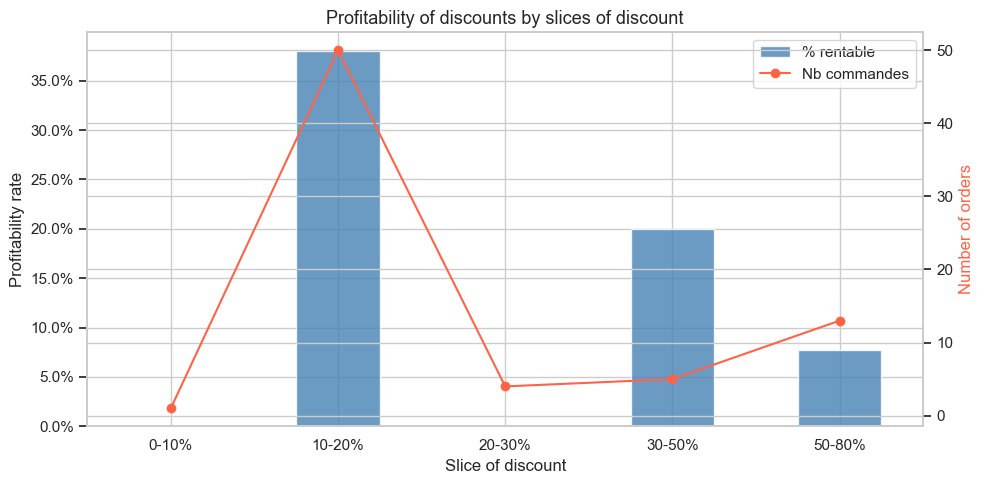

In [21]:
# Profitability rate by discount rate (discretized)
bins = [0, 0.1, 0.2, 0.3, 0.5, 0.8, 1.0]
labels = ['0-10%', '10-20%', '20-30%', '30-50%', '50-80%', '80-100%']
df_remise['tranche_remise'] = pd.cut(df_remise['Discount'], bins=bins, labels=labels)

rentab_par_tranche = df_remise.groupby('tranche_remise', observed=True)['remise_rentable'].agg(['mean','count'])
rentab_par_tranche.columns = ['taux_rentabilite', 'nb_commandes']

fig, ax1 = plt.subplots(figsize=(10, 5))
ax2 = ax1.twinx()

rentab_par_tranche['taux_rentabilite'].plot(kind='bar', ax=ax1, color='steelblue', alpha=0.8, label='% rentable')
rentab_par_tranche['nb_commandes'].plot(kind='line', ax=ax2, color='tomato', marker='o', label='Nb commandes')

ax1.set_ylabel('Profitability rate')
ax1.yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
ax2.set_ylabel('Number of orders', color='tomato')
ax1.set_title('Profitability of discounts by slices of discount')
ax1.set_xlabel('Slice of discount')
ax1.tick_params(axis='x', rotation=0)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right')

plt.tight_layout()
plt.savefig('plots/rentabilite_par_tranche.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Building the Random Forest model

### 5.1 Features preperation

In [22]:
# --- STEP 1 : Computing of comportemental features for each customer ---
# We compute on the whole dataset to get the full historic
client_features_df = df.groupby('Customer ID').agg(
    nb_commandes        = ('Order ID',                        'nunique'),
    panier_moyen        = ('Total Amount After the Discount', 'mean'),
    remise_moy_client   = ('Discount',                        'mean'),
    quantite_moy_client = ('Quantity',                        'mean'),
    revenu_total_client = ('Total Amount After the Discount', 'sum'),
).reset_index()

# --- STEP 2 : Merge on df_remise ---
df_remise = df_remise.merge(client_features_df, on='Customer ID', how='left')
print(f'✅ Merge OK — df_remise shape : {df_remise.shape}')

# --- STEP 3 : Defining features ---
features_client = [
    'nb_commandes',
    'panier_moyen',
    'remise_moy_client',
    'quantite_moy_client',
    'revenu_total_client',
]

# Categories (texte → LabelEncoder)
features_cat = ['Category', 'Sub-Category', 'Segment', 'Region', 'Ship Mode']

# Numeric (nombres → Nothing to encode)
features_num = ['Discount', 'Quantity', 'delai_livraison', 'mois_commande'] + features_client

# --- STEP 4 : Encoding et preparation ---
df_model = df_remise[features_cat + features_num + ['remise_rentable']].copy()

encoders = {}
for col in features_cat:
    le = LabelEncoder()
    df_model[col] = le.fit_transform(df_model[col].astype(str))
    encoders[col] = le

X = df_model[features_cat + features_num]
y = df_model['remise_rentable']

print(f'Features used : {list(X.columns)}')
print(f'dataset size : {X.shape}')
print(f"Targeted distribution : {y.value_counts().to_dict()}")

✅ Merge OK — df_remise shape : (73, 35)
Features used : ['Category', 'Sub-Category', 'Segment', 'Region', 'Ship Mode', 'Discount', 'Quantity', 'delai_livraison', 'mois_commande', 'nb_commandes', 'panier_moyen', 'remise_moy_client', 'quantite_moy_client', 'revenu_total_client']
dataset size : (73, 14)
Targeted distribution : {0: 52, 1: 21}


### 5.2 Training with cross validation

In [23]:
# Split train/test (stratifié pour équilibrer les classes)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

# Modèle Random Forest
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=6,
    min_samples_leaf=2,
    class_weight='balanced',  # compense un éventuel déséquilibre de classes
    random_state=42
)

rf.fit(X_train, y_train)

# Cross-validation (5 folds)
cv_scores = cross_val_score(rf, X, y, cv=5, scoring='accuracy')
print(f'✅ Cross-validation Accuracy : {cv_scores.mean():.2%} (+/- {cv_scores.std():.2%})')
print(f'   Scores per fold : {[f"{s:.2%}" for s in cv_scores]}')

✅ Cross-validation Accuracy : 68.57% (+/- 6.61%)
   Scores per fold : ['73.33%', '66.67%', '60.00%', '78.57%', '64.29%']


### 5.3 Evaluate the model on the test data 

=== Classification Report ===
                  precision    recall  f1-score   support

Non rentable (0)       0.72      0.93      0.81        14
    Rentable (1)       0.00      0.00      0.00         5

        accuracy                           0.68        19
       macro avg       0.36      0.46      0.41        19
    weighted avg       0.53      0.68      0.60        19



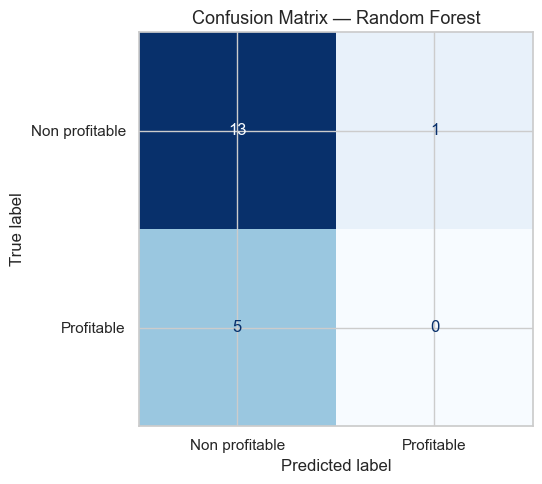

In [24]:
y_pred = rf.predict(X_test)

print('=== Classification Report ===')
print(classification_report(
    y_test, y_pred,
    target_names=['Non rentable (0)', 'Rentable (1)']
))

# Confusion Matrix
fig, ax = plt.subplots(figsize=(6, 5))
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Non profitable', 'Profitable'])
disp.plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title('Confusion Matrix — Random Forest')
plt.tight_layout()
plt.savefig('plots/confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Interpretation — Features weight in the model

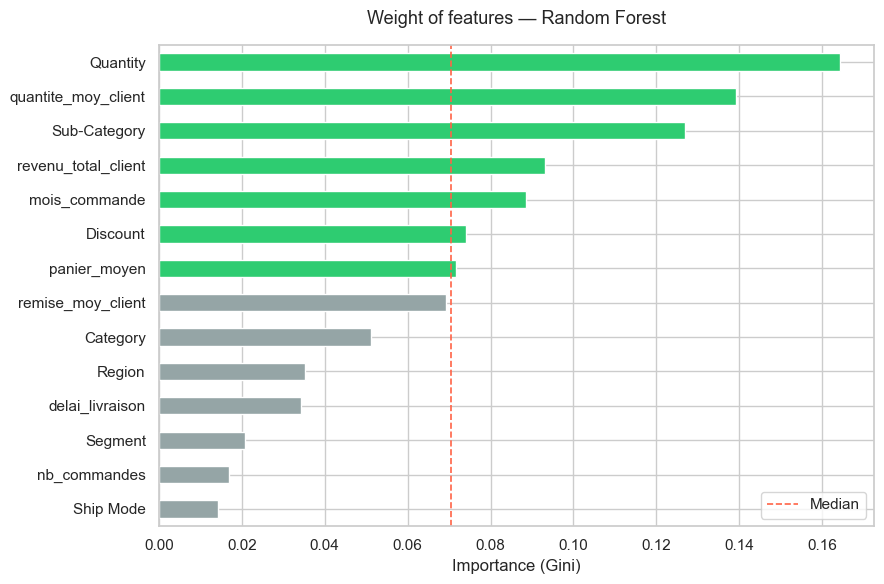


Top 3 most important features :
  → Quantity : 0.164
  → quantite_moy_client : 0.139
  → Sub-Category : 0.127


In [25]:
importances = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(9, 6))
colors = ['#2ecc71' if imp >= importances.median() else '#95a5a6' for imp in importances]
importances.plot(kind='barh', ax=ax, color=colors)
ax.set_title('Weight of features — Random Forest', pad=15)
ax.set_xlabel('Importance (Gini)')
ax.axvline(importances.median(), color='tomato', linestyle='--', linewidth=1.2, label='Median')
ax.legend()
plt.tight_layout()
plt.savefig('plots/feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nTop 3 most important features :')
for feat, imp in importances.sort_values(ascending=False).head(3).items():
    print(f'  → {feat} : {imp:.3f}')

## 7. Determining situation where discounts are profitable

In [ ]:
# Pivot table : Sub-category x discount rate per class
profil = (
    df_remise
    .groupby(['Sub-Category', 'Segment', 'remise_rentable'])
    .agg(
        nb_commandes=('Quantity', 'count'),
        remise_moyenne=('Discount', 'mean'),
        quantite_moyenne=('Quantity', 'mean'),
        revenu_moyen=('Total Amount After the Discount', 'mean')
    )
    .reset_index()
)

# Focus on profitable discounts
rentable = profil[profil['remise_rentable'] == 1].sort_values('revenu_moyen', ascending=False)
print('=== Top situation where discounts are PROFITABLE ===')
print(rentable[['Sub-Category', 'Segment', 'nb_commandes', 'remise_moyenne', 'quantite_moyenne', 'revenu_moyen']]
      .to_string(index=False))

=== Top profils où la remise est RENTABLE ===
Sub-Category     Segment  nb_commandes  remise_moyenne  quantite_moyenne  revenu_moyen
   Bookcases    CONSUMER             1             0.5               7.0      1541.720
         Art   CORPORATE             1             0.2               8.0       890.420
      Phones   CORPORATE             1             0.2               7.0       878.040
      Phones    CONSUMER             2             0.2               5.0       727.430
      Phones HOME OFFICE             1             0.2               4.0       296.930
 Accessories    CONSUMER             1             0.2               6.0       191.120
     Storage HOME OFFICE             1             0.2               3.0       184.300
 Accessories HOME OFFICE             2             0.2               4.0       174.375
   Envelopes   CORPORATE             1             0.2               7.0       160.790
   Envelopes    CONSUMER             1             0.2               6.0       104.3

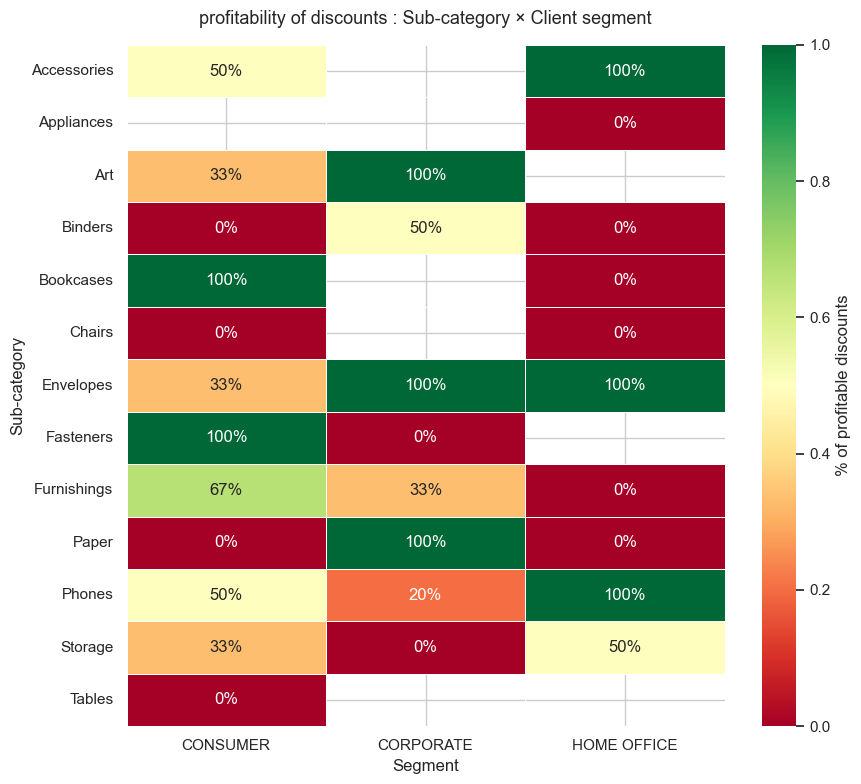

In [30]:
# Heatmap : Profitability mean, sub-category x segment
pivot = df_remise.pivot_table(
    values='remise_rentable',
    index='Sub-Category',
    columns='Segment',
    aggfunc='mean'
)

fig, ax = plt.subplots(figsize=(9, 8))
sns.heatmap(
    pivot,
    annot=True,
    fmt='.0%',
    cmap='RdYlGn',
    linewidths=0.5,
    ax=ax,
    cbar_kws={'label': '% of profitable discounts'}
)
ax.set_title('profitability of discounts : Sub-category × Client segment', pad=15)
ax.set_ylabel('Sub-category')
ax.set_xlabel('Segment')
plt.tight_layout()
plt.savefig('plots/heatmap_rentabilite.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Simulation — Optimal discount threshold

For each category, we identify the **maximum discount rate** before discounts automatically become non-profitable           

=== Threshold of discount recomanded per category ===
  Furniture            → max 0%
  Office Supplies      → max 0%
  Technology           → max 20%


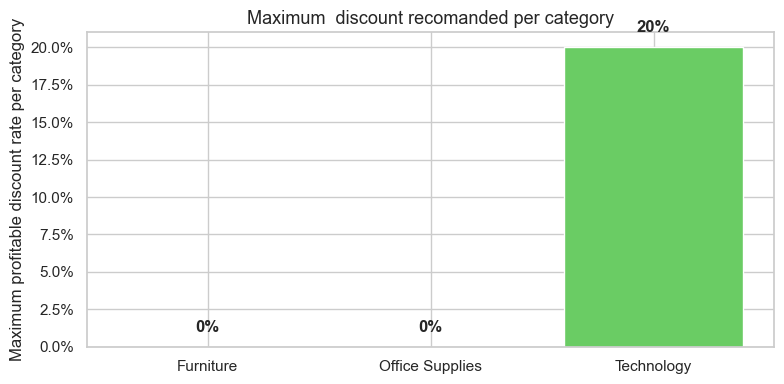

In [28]:
seuils = {}
for cat in df_remise['Category'].unique():
    sub = df_remise[df_remise['Category'] == cat].copy()
    # Searching for the discount rate from which < 50% of orders are profitable
    for seuil in np.arange(0.05, 1.0, 0.05):
        taux = sub[sub['Discount'] >= seuil]['remise_rentable'].mean()
        if pd.isna(taux) or taux < 0.5:
            seuils[cat] = round(seuil - 0.05, 2)
            break
    else:
        seuils[cat] = 0.95

print('=== Threshold of discount recomanded per category ===')
for cat, seuil in seuils.items():
    print(f'  {cat:20s} → max {seuil:.0%}')

fig, ax = plt.subplots(figsize=(8, 4))
cats = list(seuils.keys())
vals = [seuils[c] for c in cats]
bars = ax.bar(cats, vals, color=sns.color_palette('muted', len(cats)))
ax.yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
ax.set_title('Maximum  discount recomanded per category')
ax.set_ylabel('Maximum profitable discount rate per category')
for bar, val in zip(bars, vals):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, f'{val:.0%}', ha='center', fontweight='bold')
plt.tight_layout()
plt.savefig('plots/seuil_remise.png', dpi=150, bbox_inches='tight')
plt.show()

## 9. Synthesis and recommendations

In [36]:
print('=' * 55)
print('\tSynthesis of the ANALYSIS')
print('=' * 55)

total_remises = len(df_remise)
pct_rentable = df_remise['remise_rentable'].mean()
perte_totale = df_remise['perte_remise'].sum()
perte_non_rentable = df_remise[df_remise['remise_rentable'] == 0]['perte_remise'].sum()

print(f'\n📦 Discount orders analyzed : {total_remises}')
print(f'✅ Profitable discounts            : {pct_rentable:.1%}')
print(f'❌ Non profitable discounts        : {1 - pct_rentable:.1%}')
print(f'\n💸 Total loss due to discounts : {perte_totale:,.0f}')
print(f'💸 Loss not justified             : ${perte_non_rentable:,.0f}')

print(f'\n🤖 Precision of the model          : {cv_scores.mean():.1%}')
print(f'\n📌 Most important feature         : {importances.idxmax()}')
print('\n' + '=' * 55)
print('\n💡 RECOMMANDATIONS :')
print('  1. Limit discounts based on the threshold     ')
print('     determined by category (cf. graphique section 8)')
print('  2. Target in priority Corporate customers')
print('     and Technology products for discounts')
print('  3. Avoid discounts rates > 50% on Furniture/Tables')
print('     except very big orders')

	Synthesis of the ANALYSIS

📦 Discount orders analyzed : 73
✅ Profitable discounts            : 28.8%
❌ Non profitable discounts        : 71.2%

💸 Total loss due to discounts : 5,322
💸 Loss not justified             : $2,408

🤖 Precision of the model          : 68.6%

📌 Most important feature         : Quantity


💡 RECOMMANDATIONS :
  1. Limit discounts based on the threshold     
     determined by category (cf. graphique section 8)
  2. Target in priority Corporate customers
     and Technology products for discounts
  3. Avoid discounts rates > 50% on Furniture/Tables
     except very big orders
